In [1]:
from FNO2D_def import *  # your 2D FNO definition file
import h5py
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
import os
import matplotlib.pyplot as plt
import time

torch.manual_seed(0)
np.random.seed(0)

In [17]:
# Config

batch_size = 4  # reduce for 2D since fields are larger
lr = 2e-4
epochs = 500
val_patience = 25
sub = 1

modes1 = modes2 = 8
width = 128

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
time_loss = np.zeros((2,epochs))

# Paths
h5_path = path = "/scratch/mnhagen/datasets/navier_stokes_multires/navier_stokes2D_S1000_N128_multi.h5"
dataset = "omega"

In [11]:
# Dataset Definition

class NavierStokesDirectDataset(torch.utils.data.Dataset):
    """
    Dataset for learning the direct mapping ω₀ → ω_T from 2-frame trajectories.
    """

    def __init__(self, h5_path, split="train", split_ratio=(0.8, 0.2), sub = 1):
        super().__init__()
        with h5py.File(h5_path, "r") as f:
            self.omega = f[dataset][:]   # (num_samples, 2, N, N)
            self.X = f["X"][:]
            self.Y = f["Y"][:]

        self.sub = sub
        self.num_samples = self.omega.shape[0]
        n_train = int(self.num_samples * split_ratio[0])
        if split == "train":
            self.idxs = range(0, n_train)
        else:
            self.idxs = range(n_train, self.num_samples)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, idx):
        i = self.idxs[idx]
        ω_in = self.omega[i, 0, ::self.sub, ::self.sub]    # initial
        ω_out = self.omega[i, 1, ::self.sub, ::self.sub]   # final

        # Add channel dimension (1, H, W)
        ω_in = torch.tensor(ω_in[None, :, :], dtype=torch.float32)
        ω_out = torch.tensor(ω_out[None, :, :], dtype=torch.float32)
        return ω_in, ω_out


In [18]:
#Train model

train_ds = NavierStokesDirectDataset(h5_path, split="train", sub = sub)
val_ds = NavierStokesDirectDataset(h5_path, split="val", sub = sub)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

model = FNO2D(modes1, modes2, width)
model.q = torch.nn.Conv2d(width, 1, 1)  # one output channel (vorticity)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_loss = float("inf")
epochs_no_improve = 0

start_time = time.time()
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for ω_in, ω_target in train_loader:
        ω_in, ω_target = ω_in.to(device), ω_target.to(device)
        optimizer.zero_grad()

        ω_pred = model(ω_in.permute(0, 2, 3, 1))  # (B, H, W, 1)
        ω_pred = ω_pred.permute(0, 3, 1, 2)       # back to (B, 1, H, W)

        loss = F.mse_loss(ω_pred, ω_target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for ω_in, ω_target in val_loader:
            ω_in, ω_target = ω_in.to(device), ω_target.to(device)
            ω_pred = model(ω_in.permute(0, 2, 3, 1))
            ω_pred = ω_pred.permute(0, 3, 1, 2)
            val_loss += F.mse_loss(ω_pred, ω_target).item()
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4e} | Val: {val_loss:.4e}")

    # Early stopping
    if val_loss < best_val_loss * (1-1e-3):
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= val_patience:
            print("Early stop triggered.")
            break

    # Early stopping
    if val_loss < best_val_loss * (1 - 1e-3):
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0

    else:
        if best_val_loss * (1 - 1e-3) < val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve += 1
        if epochs_no_improve >= val_patience:
            print("Early stop triggered.")
            break

    time_loss[0][epoch] = time.time() - start_time
    time_loss[1][epoch] = val_loss

time_loss = time_loss[:, :epoch]
model.load_state_dict(best_state)

print("Training complete. Best val loss:", best_val_loss)


Epoch 000 | Train: 1.3050e-01 | Val: 7.6841e-02
Epoch 001 | Train: 7.0450e-02 | Val: 6.2377e-02
Epoch 002 | Train: 6.0195e-02 | Val: 5.5839e-02
Epoch 003 | Train: 5.4438e-02 | Val: 5.0961e-02
Epoch 004 | Train: 4.8649e-02 | Val: 4.5020e-02
Epoch 005 | Train: 4.1846e-02 | Val: 3.8530e-02
Epoch 006 | Train: 3.5899e-02 | Val: 3.4199e-02
Epoch 007 | Train: 3.1947e-02 | Val: 3.1213e-02
Epoch 008 | Train: 2.8869e-02 | Val: 2.9079e-02
Epoch 009 | Train: 2.6172e-02 | Val: 2.6634e-02
Epoch 010 | Train: 2.3811e-02 | Val: 2.4789e-02
Epoch 011 | Train: 2.1645e-02 | Val: 2.2958e-02
Epoch 012 | Train: 1.9717e-02 | Val: 2.1244e-02
Epoch 013 | Train: 1.8044e-02 | Val: 1.9697e-02
Epoch 014 | Train: 1.6511e-02 | Val: 1.8488e-02
Epoch 015 | Train: 1.5175e-02 | Val: 1.7335e-02
Epoch 016 | Train: 1.3999e-02 | Val: 1.6257e-02
Epoch 017 | Train: 1.3005e-02 | Val: 1.5517e-02
Epoch 018 | Train: 1.2081e-02 | Val: 1.4587e-02
Epoch 019 | Train: 1.1267e-02 | Val: 1.4047e-02
Epoch 020 | Train: 1.0605e-02 | Val: 1.3

In [19]:
#Save model

model_name = "FNO2D_navier_stokes_N128_k8(half)"

model_dir = "/scratch/mnhagen/models/navier_stokes"
model_loss_name = model_name + "_loss"
model_path = os.path.join(model_dir, model_name + ".pt")
model_loss_path = os.path.join(model_dir, model_loss_name + ".csv")

model_dir = "/scratch/mnhagen/models/navier_stokes"
os.makedirs(model_dir, exist_ok=True)
save_path = os.path.join(model_dir, model_name + ".pt")

torch.save(model.state_dict(), save_path)
print(f"Model saved to {model_path}")

np.savetxt(
    model_loss_path,
    time_loss,
    delimiter=",",
    fmt="%.6f"   # controls number formatting
)
print(f"Model loss saved to {model_loss_path}")

Model saved to /scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N128_k8(half).pt
Model loss saved to /scratch/mnhagen/models/navier_stokes/FNO2D_navier_stokes_N128_k8(half)_loss.csv


The code below is for plotting model predictions; either skip the load model cell to use the model just trained or load a model to test

In [ ]:
#Load model

load_path = "/scratch/mnhagen/models/heat2d/FNO2D_heat2d_multi128.pt"
h5_path = path = "/scratch/mnhagen/datasets/heat2d_multires/heat2D_autoreg_N256_multi.h5"

model = FNO2D(modes1, modes2, width)
model.q = torch.nn.Conv2d(width, 1, 1)  # one output channel (vorticity)
model.load_state_dict(torch.load(load_path, map_location=device))
model.to(device)
model.eval()

FNO2D(
  (p): Linear(in_features=3, out_features=128, bias=True)
  (conv0): SpectralConv2d()
  (conv1): SpectralConv2d()
  (conv2): SpectralConv2d()
  (conv3): SpectralConv2d()
  (mlp0): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (mlp1): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (mlp2): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (mlp3): MLP(
    (mlp1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (mlp2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (w0): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (w1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (w3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1,

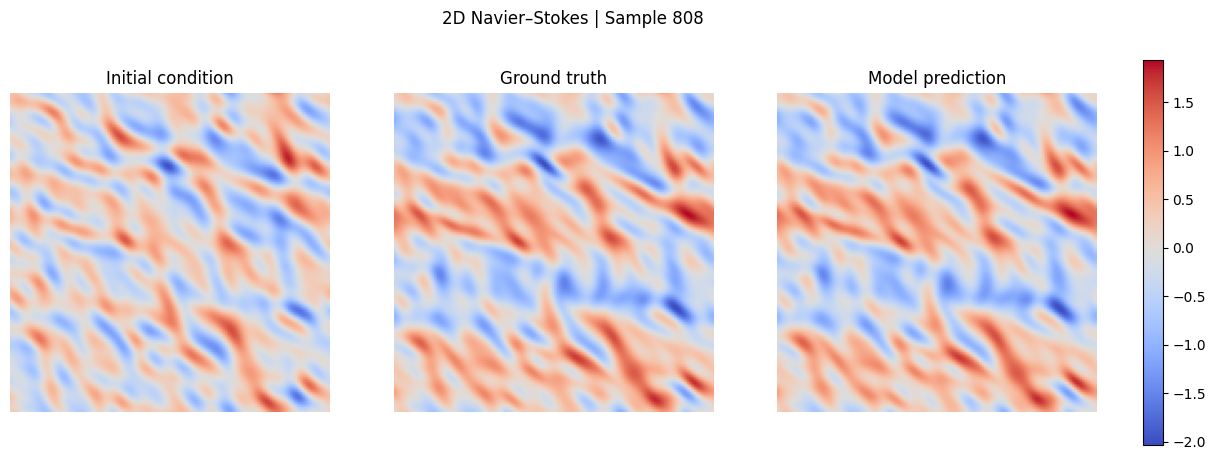

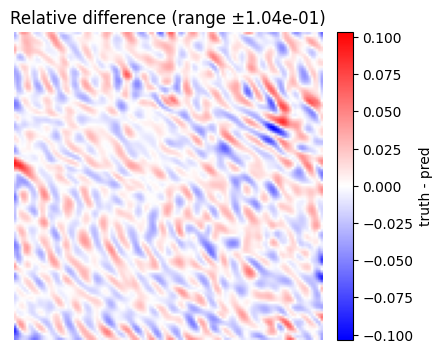

In [8]:
# Plot model prediction

sample_idx = 808

with h5py.File(h5_path, "r") as f:
    omega = f[dataset][:]  # (num_samples, 2, N, N)
omega0 = omega[sample_idx, 0, ::sub, ::sub]
omegaT = omega[sample_idx, 1, ::sub, ::sub]


ω_in = torch.tensor(omega0[None, None, :, :], dtype=torch.float32).to(device)  # (1,1,H,W)
with torch.no_grad():
    ω_pred = model(ω_in.permute(0, 2, 3, 1))  # -> (1,H,W,1)
ω_pred = ω_pred[0, ..., 0].cpu().numpy()  # (H,W)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Initial condition", "Ground truth", "Model prediction"]
fields = [omega0, omegaT, ω_pred]

vmin = min(np.min(f) for f in fields)
vmax = max(np.max(f) for f in fields)

for ax, field, title in zip(axes, fields, titles):
    im = ax.imshow(field, cmap="coolwarm", origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
plt.suptitle(f"2D Navier–Stokes | Sample {sample_idx}")
#plt.tight_layout()
plt.show()


diff = omegaT - ω_pred
max_abs_diff = np.max(np.abs(diff))

plt.figure(figsize=(5, 4))
plt.imshow(diff, cmap="bwr", origin="lower",
           vmin=-max_abs_diff, vmax=max_abs_diff)
plt.colorbar(fraction=0.046, pad=0.04, label="truth - pred")
plt.title(f"Relative difference (range ±{max_abs_diff:.2e})")
plt.axis("off")
plt.show()